In [1]:
import sys

sys.path.append("..")
sys.path.append("../..")

In [2]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

from utils.misc import load_config
from datasets.data_preparation import prepare_data
from engine.vit import train
from utils.misc import plot_confusion_matrix, plot_loss_accuracy_curve

/home/nasim/anaconda3/envs/ML/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
exp_path = '../../results/dl.ann/2023-09-12 11Hr 45Min 14Sec IST+0530'

config = load_config('.', exp_path, 'hyperparameters.yaml')

In [4]:
trainer_config = config['trainer']
data_config = config['data']

checkpoint_name = trainer_config['checkpoint_name']
device = trainer_config['device']
config['data']['scaled_columns'] = [] #testing
batch_size = trainer_config['batch_size']

patch_size = data_config['patch']['patch_size']
config['model']['loss_weights'] = [1,1,1] #testing
data_config['class_weights'] = [1,1,1,1,1,1] #testing
lithology_classes = data_config['lithology_classes']

config['root'] = '../..'

In [6]:
x_train, x_val, y_train, y_val, num_classes = prepare_data(config, test = False, scaler_save=False)

Preparing the data...


Creating Patches: 100%|██████████| 902/902 [00:20<00:00, 44.59it/s]

Number of classes: 6 and shape of x_train: torch.Size([1133, 150, 5])


In [7]:
traindataset = TensorDataset(x_train, y_train)
trainloader = DataLoader(traindataset, batch_size=batch_size, shuffle=True)

valdataset = TensorDataset(x_val, y_val)
valloader = DataLoader(valdataset, batch_size=batch_size, shuffle=True)

# invert key as value and value as key
lithology_names = {v: k for k, v in lithology_classes.items()}

In [8]:
from model.utils import get_activation

class WellLogRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, patch_size, activation='relu'):
        super(WellLogRNN, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.activation = nn.ReLU()  # Activation function

        dim = hidden_size

        self.sw_head = nn.Sequential(
            nn.LayerNorm(dim+num_classes+1),
            get_activation(activation),
            nn.Linear(dim+num_classes+1, dim//2),
            nn.LayerNorm(dim//2),
            get_activation(activation),
            nn.Linear(dim//2, 1)
        )

        self.lithology_head = nn.Sequential(
            nn.LayerNorm(dim),
            get_activation(activation),
            nn.Linear(dim, dim//2),
            nn.LayerNorm(dim//2),
            get_activation(activation),
            nn.Linear(dim//2, num_classes)
        )

        self.phi_head = nn.Sequential(
            nn.LayerNorm(dim+num_classes),
            get_activation(activation),
            nn.Linear(dim+num_classes, dim//2),
            nn.LayerNorm(dim//2),
            get_activation(activation),
            nn.Linear(dim//2, 1)
        )
        
    def forward(self, x):
        x, _ = self.rnn(x)
        x = self.activation(x)  # Apply activation function

        lith_output = self.lithology_head(x)
        lith_output_prob = lith_output.softmax(dim=-1)

        x_lith = torch.cat((x, lith_output_prob), dim=2)
        phi_output = self.phi_head(x_lith)

        x_lith_phi = torch.cat((x, lith_output_prob, phi_output), dim=2)
        sw_output = self.sw_head(x_lith_phi).sigmoid()

        return lith_output, phi_output, sw_output

In [9]:
hidden_size = 32
num_layers = 1
model = WellLogRNN(data_config['num_features'], hidden_size, num_layers, num_classes, data_config['patch']['patch_size'])
model = model.to('cuda')

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [12]:
classification_criterion = nn.CrossEntropyLoss(weight=torch.tensor(data_config['class_weights']).float().to(device))
regression_criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
(
    train_losses, 
    val_losses, 
    train_lith_losses,
    val_lith_losses,
    train_phi_losses,
    val_phi_losses,
    train_sw_losses,
    val_sw_losses,
    train_accuracies, 
    val_accuracies, 
    best_epoch, 
    best_loss, 
    best_accuracy,
    best_cm_val, 
    best_cm, 
    best_model_chkpt, 
    best_optim_chkpt
) = train(
    100, 
    model, 
    trainloader, 
    valloader, 
    regression_criterion,
    classification_criterion,
    config['model']['loss_weights'],
    optimizer, 
    10,
    device
)

Val - Epoch 1/100: 100%|██████████| 2/2 [00:00<00:00, 109.12it/s]


Epoch 1/100, Train Lith Loss: 1.9032, Train Phi Loss: 0.2547, Train Sw Loss: 0.1966, Train Loss: 2.3545, Train Accuracy: 16.3830, Val Lith Loss: 1.8559, Val Phi Loss: 0.1652, Val Sw Loss: 0.1789, Val Loss: 2.2000, Val Accuracy: 18.7755
Model Performance Improved from epoch no. 1


Val - Epoch 2/100: 100%|██████████| 2/2 [00:00<00:00, 123.14it/s]


Epoch 2/100, Train Lith Loss: 1.8256, Train Phi Loss: 0.1131, Train Sw Loss: 0.1613, Train Loss: 2.1000, Train Accuracy: 24.1573, Val Lith Loss: 1.7981, Val Phi Loss: 0.0551, Val Sw Loss: 0.1349, Val Loss: 1.9880, Val Accuracy: 24.9939
Model Performance Improved from epoch no. 0


Val - Epoch 3/100: 100%|██████████| 2/2 [00:00<00:00, 128.48it/s]


...

Epoch 98/100, Train Lith Loss: 0.3526, Train Phi Loss: 0.0013, Train Sw Loss: 0.0163, Train Loss: 0.3703, Train Accuracy: 89.6086, Val Lith Loss: 0.3663, Val Phi Loss: 0.0011, Val Sw Loss: 0.0126, Val Loss: 0.3800, Val Accuracy: 88.6138


Val - Epoch 99/100: 100%|██████████| 2/2 [00:00<00:00, 90.91it/s]


Epoch 99/100, Train Lith Loss: 0.3487, Train Phi Loss: 0.0013, Train Sw Loss: 0.0160, Train Loss: 0.3660, Train Accuracy: 89.8954, Val Lith Loss: 0.3505, Val Phi Loss: 0.0012, Val Sw Loss: 0.0140, Val Loss: 0.3657, Val Accuracy: 89.9076


Val - Epoch 100/100: 100%|██████████| 2/2 [00:00<00:00, 125.35it/s]

Epoch 100/100, Train Lith Loss: 0.3419, Train Phi Loss: 0.0013, Train Sw Loss: 0.0163, Train Loss: 0.3595, Train Accuracy: 90.1771, Val Lith Loss: 0.3608, Val Phi Loss: 0.0012, Val Sw Loss: 0.0123, Val Loss: 0.3743, Val Accuracy: 88.7130


In [14]:
# plot_confusion_matrix(best_cm, best_cm_val, lithology_classes, save_path=False)
# plot_loss_accuracy_curve(train_losses, val_losses,train_accuracies,val_accuracies,save_path='')

/home/nasim/phd/petro_AViT/notebooks/ml/../../utils/misc.py:451: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(cm) / np.sum(cm, axis = 0)


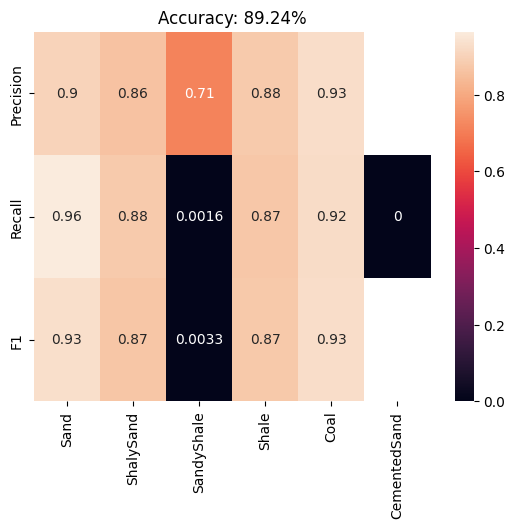

In [15]:
from utils.misc import precision_recall_f1_score
precision_recall_f1_score(best_cm, lithology_classes)

In [16]:
val_accuracies[best_epoch], val_phi_losses[best_epoch], val_sw_losses[best_epoch]

(89.02529907226562, 0.0011072265578275283, 0.014423027314401569)

In [17]:
config['data']['x_file_name'] = 'blind_X.h5'
config['data']['y_file_name'] = 'blind_Y.h5'

x_blind, x, y_blind, y, _ = prepare_data(config, test = False, scaler_save=False)

x_blind = torch.cat([x_blind, x], dim=0)
y_blind = torch.cat([y_blind, y], dim=0)

blind_dataset = TensorDataset(x_blind, y_blind)
blindloader = DataLoader(blind_dataset, batch_size=batch_size, shuffle=True)

Preparing the data...


Creating Patches: 100%|██████████| 10/10 [00:00<00:00, 545.44it/s]

Number of classes: 6 and shape of x_train: torch.Size([13, 150, 5])


In [18]:
from engine.vit import validation_engine as blind_engine

In [19]:
model.load_state_dict(best_model_chkpt)

<All keys matched successfully>

In [25]:
# regression_criterion = nn.L1Loss()
regression_criterion = nn.MSELoss()

In [26]:
val_loss, lith_val_loss, phi_val_loss, sw_val_loss, val_accuracy, cm_val = blind_engine(1,
                                                    model,
                                                    blindloader,
                                                    regression_criterion,
                                                    classification_criterion,
                                                    2,
                                                    config['model']['loss_weights'],
                                                    device,)

Val - Epoch 2/2: 100%|██████████| 1/1 [00:00<00:00, 33.19it/s]


In [27]:
phi_val_loss, sw_val_loss

(0.0010319756140806948, 0.010445186438752762)

In [23]:
val_accuracy

89.80392456054688

/home/nasim/phd/petro_AViT/notebooks/ml/../../utils/misc.py:451: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(cm) / np.sum(cm, axis = 0)


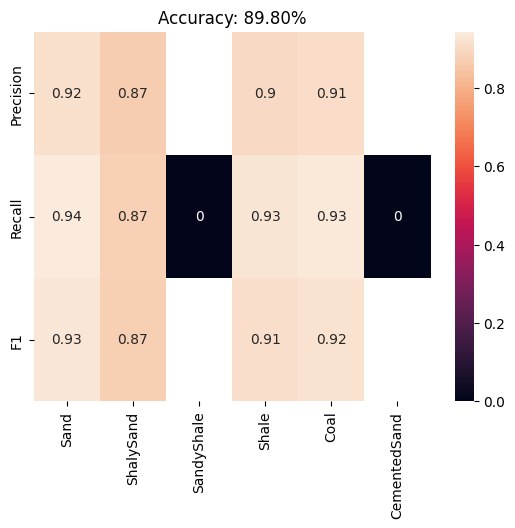

In [24]:
precision_recall_f1_score(cm_val, lithology_classes)